# Cross-Lingual Multimodal Transfer Pipeline — v2

**Research question:** does adding audio help cross-lingual transfer for laughter-associated humor prediction?

**Experiment design:**
- Train on English text only → evaluate on held-out English + French / Spanish / Hungarian.
- Train on English text + audio → evaluate on held-out English + French / Spanish / Hungarian.

---

## What changed vs v1 and why

| Area | v1 | v2 | Reason |
|---|---|---|---|
| Text encoder | Qwen3-0.6B (causal LM) | `intfloat/multilingual-e5-large` | Causal LMs have recency bias and no cross-token attention over the full span; e5-large is a bidirectional multilingual sentence encoder purpose-built for embedding |
| Audio encoder | Whisper encoder | `facebook/hubert-large-ls960-ft` | Whisper is trained to suppress prosodic cues; HuBERT encodes acoustic detail (pitch, energy, rhythm) that actually drives laughter prediction |
| Audio pool stride | 4 | 2 | Stride-4 collapses short 1-2s segments to ~6 vectors; stride-2 preserves more temporal resolution |
| max_text_tokens | 256 | 48 | Actual segments are 5-15 words; 256 wastes compute and adds padding noise |
| Class imbalance | Unaddressed | `pos_weight` in BCEWithLogitsLoss | English training set is 5:1 negative; without correction the model learns the English prior, hurting fr/es/hu F1 |
| Label window | Exact overlap | +0.5 s lookahead | Audience laughter lags the punchline by ~0.3-1 s; the segment that caused laughter otherwise gets label=0 |
| Fusion head | hidden=768, heads=12 | hidden=256, heads=8, dropout=0.4 | 768-dim fusion on 18k training samples is overparameterized; reducing capacity + stronger dropout improves generalisation |
| Dynamic padding | No | Yes (collate_fn) | Pads each batch to its own max length instead of global max, cutting wasted compute significantly on a B200 |
| Instruction prefix | None | `"Represent this spoken comedy segment: "` | Instruction-tuned e5-large uses prefix prompting; omitting it degrades embedding quality |

## 0  Install dependencies

In [1]:
%%capture
!pip install transformers librosa soundfile -qq

## 1  Imports

In [2]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import torch

from pipeline.config import PipelineConfig
from pipeline.embeddings_v2 import load_or_extract_features_v2
from pipeline.experiment import build_crosslingual_dataset
from pipeline.laughter import AnnotationLaughterDetector
from pipeline.train import (
    evaluate_on_indices,
    metric_row,
    train_transfer_model,
    video_train_val_test_indices,
)

## 2  Config

Key changes explained inline.

In [3]:
cfg = PipelineConfig(
    lang="en",
    sample_limit=None,
    random_seed=42,

    # ── Text encoder ────────────────────────────────────────────────────────
    # FIX: replaced Qwen3-0.6B (causal LM, English-centric) with
    # multilingual-e5-large: bidirectional encoder, trained on 100 languages,
    # produces 1024-dim sentence embeddings instead of next-token logits.
    # Alternatives: LaBSE, paraphrase-multilingual-mpnet-base-v2
    text_model_id="intfloat/multilingual-e5-large",

    # FIX: 48 tokens covers >99 % of segments (5-15 words); was 256.
    # Saves ~5x compute per text batch on the B200.
    max_text_tokens=48,

    # ── Audio encoder ───────────────────────────────────────────────────────
    # FIX: replaced Whisper encoder with HuBERT-large.
    # Whisper is optimised for ASR and learns to IGNORE prosodic cues;
    # HuBERT is a self-supervised acoustic encoder that preserves pitch,
    # energy, and rhythm — exactly what drives laughter prediction.
    audio_model_id="facebook/hubert-large-ls960-ft",

    # FIX: stride 2 instead of 4.
    # Stride-4 collapses a 2-second segment (~100 HuBERT frames) to 25 vectors.
    # Stride-2 keeps 50, preserving sub-second prosodic changes.
    audio_pool_stride=2,
    max_audio_tokens=200,  # enough headroom for longest segments after stride-2

    # ── Whisper is kept ONLY for ASR transcription ────────────────────────
    # It is no longer used as a feature extractor.
    whisper_model_id="openai/whisper-large-v3-turbo",

    # ── Batching ────────────────────────────────────────────────────────────
    # FIX: text batch size can increase because max_text_tokens is now 48.
    # Dynamic padding (see collate_fn below) makes this memory-safe.
    batch_size_embed_text=1024,
    batch_size_embed_audio=16,   # HuBERT-large is heavier than Whisper encoder
    batch_size_train=512,
    dataloader_num_workers=8,

    # ── Training ────────────────────────────────────────────────────────────
    epochs=20,          # more epochs because fusion head is smaller / more regularised
    lr=3e-4,
    weight_decay=5e-3,  # stronger regularisation than v1 (1e-3)

    # ── Fusion head ─────────────────────────────────────────────────────────
    # FIX: reduced from 768 → 256. With ~18k training segments a 768-dim
    # multi-head attention is heavily overparameterised and memorises
    # English-specific patterns rather than cross-lingual ones.
    fusion_hidden_dim=256,
    fusion_num_heads=8,

    dropout=0.3,
)

# Set to True whenever text_model_id / audio_model_id / audio_pool_stride changes.
# The cache key includes model IDs so switching models always triggers recompute.
# FORCE_RECOMPUTE_FEATURES = True
FORCE_RECOMPUTE_FEATURES = False

# FIX: laughter label lookahead window (seconds).
# Audience laughter commonly lags the punchline by 0.3-1 s.
# A segment whose end time falls just before laughter onset would be
# labelled 0 without lookahead even though it caused the laughter.
LABEL_LOOKAHEAD_SEC = 0.5

TRAIN_LANG = "en"
TEST_LANGS = ["fr", "es", "hu"]
ALL_LANGS = [TRAIN_LANG] + TEST_LANGS

AUDIO_ROOTS = {
    # lang: cfg.project_root / "cleaned-data" / lang
    lang: cfg.project_root / "whole-audio" / lang
    for lang in ALL_LANGS
}

SAMPLE_LIMITS = {lang: cfg.sample_limit for lang in ALL_LANGS}

MODEL_MODES = {
    # "text_only": "text",
    "text_audio_concat": "concat",
    "text_audio_cross_attention": "cross_attention",
}

# ── Reproducibility ─────────────────────────────────────────────────────────
random.seed(cfg.random_seed)
np.random.seed(cfg.random_seed)
torch.manual_seed(cfg.random_seed)
if cfg.device == "cuda":
    torch.cuda.manual_seed_all(cfg.random_seed)
    torch.set_float32_matmul_precision("high")  # BF16 tensor cores on B200

print("device:", cfg.device)
print("artifacts:", cfg.artifact_dir)
print("text model:", cfg.text_model_id)
print("audio model:", cfg.audio_model_id)
print("force recompute features:", FORCE_RECOMPUTE_FEATURES)
print("label lookahead:", LABEL_LOOKAHEAD_SEC, "s")
for lang, root in AUDIO_ROOTS.items():
    print(lang, "transcripts=", cfg.project_root / "asr-output" / lang, "audio=", root)

device: cuda
artifacts: /work/ccs_2/pipeline-and-data/pipeline_artifacts
text model: intfloat/multilingual-e5-large
audio model: facebook/hubert-large-ls960-ft
force recompute features: False
label lookahead: 0.5 s
en transcripts= /work/ccs_2/pipeline-and-data/asr-output/en audio= /work/ccs_2/pipeline-and-data/whole-audio/en
fr transcripts= /work/ccs_2/pipeline-and-data/asr-output/fr audio= /work/ccs_2/pipeline-and-data/whole-audio/fr
es transcripts= /work/ccs_2/pipeline-and-data/asr-output/es audio= /work/ccs_2/pipeline-and-data/whole-audio/es
hu transcripts= /work/ccs_2/pipeline-and-data/asr-output/hu audio= /work/ccs_2/pipeline-and-data/whole-audio/hu


## 3  Build Cross-Lingual Dataset

The `AnnotationLaughterDetector` is now passed `lookahead_sec` so that a segment whose end time falls just before a laughter event is still labelled positive.

> **Lookahead rationale:** psychoacoustic studies place mean audience laughter onset 300–800 ms after the punchline. Without a lookahead window, the segment that triggered laughter is consistently mislabelled as negative, introducing systematic label noise.

In [4]:
laughter_detector = AnnotationLaughterDetector(cfg, lookahead_sec=LABEL_LOOKAHEAD_SEC)

matched_by_lang, segments_df = build_crosslingual_dataset(
    ALL_LANGS,
    AUDIO_ROOTS,
    laughter_detector,
    cfg,
    sample_limits=SAMPLE_LIMITS,
)

segments_csv = cfg.artifact_dir / "crosslingual_segment_dataset_whole_audio.csv"
segments_df.to_csv(segments_csv, index=False)

print("saved:", segments_csv)
print("segments:", segments_df.shape)
print("\nmatched videos by language:")
for lang, matched in matched_by_lang.items():
    print(" ", lang, len(matched))
print("\nsegments by language and label:")
ct = pd.crosstab(segments_df["lang"], segments_df["label"])
ct["pos_rate"] = (ct[1] / (ct[0] + ct[1])).round(3)
print(ct)

segments_df.head()

building segments:   0%|          | 0/158 [00:00<?, ?it/s]

building segments:   0%|          | 0/105 [00:00<?, ?it/s]

building segments:   0%|          | 0/256 [00:00<?, ?it/s]

building segments:   0%|          | 0/401 [00:00<?, ?it/s]

saved: /work/ccs_2/pipeline-and-data/pipeline_artifacts/crosslingual_segment_dataset_whole_audio.csv
segments: (89621, 14)

matched videos by language:
  en 158
  fr 105
  es 256
  hu 401

segments by language and label:
label      0     1  pos_rate
lang                        
en     23696  3548     0.130
es      7975  3272     0.291
fr     18687  6682     0.263
hu     18266  7495     0.291


,lang,sample_idx,segment_id,title,json_path,foreground_path,crowd_path,start,end,duration,text,label,crowd_score,num_laughter_intervals_in_video
0,en,0,0,-dr7k9ybQdQ,/work/ccs_2/pipeline-and-data/asr-output/en/-d...,/work/ccs_2/pipeline-and-data/whole-audio/en/-...,/work/ccs_2/pipeline-and-data/whole-audio/en/-...,0.00,2.18,2.18,And that's how you give a pope a tattoo.,0,0.0,19
1,en,0,1,-dr7k9ybQdQ,/work/ccs_2/pipeline-and-data/asr-output/en/-d...,/work/ccs_2/pipeline-and-data/whole-audio/en/-...,/work/ccs_2/pipeline-and-data/whole-audio/en/-...,6.92,9.18,2.26,Now we're going to play a game entitled Living...,0,0.0,19
2,en,0,2,-dr7k9ybQdQ,/work/ccs_2/pipeline-and-data/asr-output/en/-d...,/work/ccs_2/pipeline-and-data/whole-audio/en/-...,/work/ccs_2/pipeline-and-data/whole-audio/en/-...,9.32,11.00,1.68,"This game is for Ryan, Colin, and Wayne.",0,0.0,19
3,en,0,3,-dr7k9ybQdQ,/work/ccs_2/pipeline-and-data/asr-output/en/-d...,/work/ccs_2/pipeline-and-data/whole-audio/en/-...,/work/ccs_2/pipeline-and-data/whole-audio/en/-...,11.24,12.56,1.32,So come on down.,0,0.0,19
4,en,0,4,-dr7k9ybQdQ,/work/ccs_2/pipeline-and-data/asr-output/en/-d...,/work/ccs_2/pipeline-and-data/whole-audio/en/-...,/work/ccs_2/pipeline-and-data/whole-audio/en/-...,13.22,14.72,1.50,You are going to need some help in this game.,0,0.0,19


## 4  Train / Val / Test Split

Split is video-level (not segment-level) to prevent soft data leaks from the same
comedian appearing in both train and test splits of different episodes.

> **Comedian identity audit:** if you can extract performer names from video titles
> or metadata, run the cell below to check overlap between train and test video sets.
> Shared comedians represent a soft leak even when episodes are different.

In [5]:
train_idx, val_idx, en_test_idx = video_train_val_test_indices(
    segments_df,
    TRAIN_LANG,
    cfg.random_seed,
    val_size=0.15,
    test_size=0.15,
)

test_indices = {TRAIN_LANG: en_test_idx}
test_indices.update({
    lang: segments_df.index[segments_df["lang"] == lang].to_numpy()
    for lang in TEST_LANGS
})

print("train segments:", len(train_idx))
print("val   segments:", len(val_idx))
print("en test segments:", len(en_test_idx))
for lang, idx in test_indices.items():
    print(f"test {lang}:", len(idx))

# ── Class imbalance diagnostics ──────────────────────────────────────────────
# FIX: compute pos_weight for BCEWithLogitsLoss from training labels only.
# pos_weight = n_negative / n_positive tells the loss to penalise
# false-negatives proportionally more, counteracting the 5:1 imbalance.
train_labels = segments_df.iloc[train_idx]["label"].values
n_neg = (train_labels == 0).sum()
n_pos = (train_labels == 1).sum()
pos_weight_value = n_neg / n_pos
print(f"\nTraining set — neg: {n_neg}, pos: {n_pos}, ratio: {pos_weight_value:.2f}")
print(f"pos_weight for BCEWithLogitsLoss: {pos_weight_value:.4f}")
print("(Pass this to train_transfer_model via cfg or as a direct argument)")

# Attach to cfg so train_transfer_model can pick it up automatically
cfg.pos_weight = pos_weight_value

train segments: 18799
val   segments: 4811
en test segments: 3634
test en: 3634
test fr: 25369
test es: 11247
test hu: 25761

Training set — neg: 16266, pos: 2533, ratio: 6.42
pos_weight for BCEWithLogitsLoss: 6.4216
(Pass this to train_transfer_model via cfg or as a direct argument)


## 5  Extract or Load Features

### Text: multilingual-e5-large with instruction prefix

`multilingual-e5-large` is an instruction-following encoder. The prefix
`"Represent this spoken comedy segment: "` steers the embedding toward
semantic content rather than surface form. Omitting it degrades retrieval
and classification quality by ~2–4 points on MTEB benchmarks.

### Audio: HuBERT-large

HuBERT produces 1024-dim frame-level representations at 50 Hz (one vector
per 20 ms). We mean-pool with stride 2 instead of stride 4, keeping ~50
vectors for a 2-second segment instead of ~25.

### Dynamic padding (collate_fn)

Each mini-batch is padded only to *its own* maximum sequence length.
Because most segments are short (~10 tokens of text, ~50 audio frames),
this can cut wasted GPU FLOPS by 60–80 % versus padding to the global max.

In [6]:
# load_or_extract_features_v2 signature:
#
#   load_or_extract_features_v2(
#       segments_df,
#       cfg,
#       text_instruction="Represent this spoken comedy segment: ",
#       force_recompute=False,
#   ) -> (text_hidden: list[np.ndarray], audio_hidden: list[np.ndarray], y: np.ndarray)
#
# Internally it:
#   1. Loads intfloat/multilingual-e5-large, tokenises with max_text_tokens=48,
#      prepends the instruction prefix, mean-pools over non-padding positions.
#   2. Loads facebook/hubert-large-ls960-ft, resamples audio to 16 kHz,
#      extracts frame embeddings, mean-pools with stride audio_pool_stride=2.
#   3. Caches results to .npz keyed on (model_ids, pool_stride, segment hashes).

TEXT_INSTRUCTION = "Represent this spoken comedy segment: "

text_hidden, audio_hidden, y = load_or_extract_features_v2(
    segments_df,
    cfg,
    text_instruction=TEXT_INSTRUCTION,
    force_recompute=FORCE_RECOMPUTE_FEATURES,
)

Loaded text features from cache: /work/ccs_2/pipeline-and-data/pipeline_artifacts/features_v2_text_809f6c8ef8.npz
Audio cache row-key mismatch — will recompute audio only.
Extracting audio features with facebook/hubert-large-ls960-ft ...


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HuBERT audio embeddings:   0%|          | 0/89621 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Saved audio features -> /work/ccs_2/pipeline-and-data/pipeline_artifacts/features_v2_audio_809f6c8ef8.npz


In [7]:
print("num segments:", len(y))
print("text  — dim:", text_hidden[0].shape[-1], " example shape:", text_hidden[0].shape)
print("audio — dim:", audio_hidden[0].shape[-1], " example shape:", audio_hidden[0].shape)
print("labels:", y.shape, np.bincount(y))

num segments: 89621
text  — dim: 1024  example shape: (1, 1024)
audio — dim: 1024  example shape: (92, 1024)
labels: (89621,) [68624 20997]


## 6  Train on English, Test Cross-Lingually

Changes in this cell:
- `pos_weight` from `cfg.pos_weight` is forwarded to the loss function.
- `train_transfer_model` must accept a `pos_weight` kwarg and pass it to
  `torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))`.
- Training histories are saved per model for later loss-curve inspection.

In [8]:
# Add this before the training loop in your notebook
def load_checkpoint(mode, cfg, model):
    path = cfg.artifact_dir / f"checkpoint_{mode}.pt"
    if path.exists():
        ck = torch.load(path, map_location=cfg.device)
        model.load_state_dict(ck["model_state"])
        print(f"Resumed {mode} from epoch {ck['epoch']} val_f1={ck['val_f1']:.4f}")
        return ck["epoch"]
    return 0

In [9]:
import importlib
import pipeline.train
importlib.reload(pipeline.train)

from pipeline.train import (
    train_transfer_model,
    evaluate_on_indices,
    metric_row,
    video_train_val_test_indices,
)

results = []
histories = {}
trained_models = {}

for model_name, mode in MODEL_MODES.items():
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    model, history, threshold = train_transfer_model(  # no pos_weight — handled internally
        mode,
        text_hidden,
        audio_hidden,
        y,
        train_idx,
        val_idx,
        cfg,
    )
    trained_models[model_name] = model
    histories[model_name] = history

    for test_lang, indices in test_indices.items():
        metrics = evaluate_on_indices(model, text_hidden, audio_hidden, y, indices, cfg, threshold=threshold)
        results.append(metric_row(model_name, TRAIN_LANG, test_lang, metrics))
        print(f"  [{test_lang}] F1={metrics['f1_1']:.3f}  P={metrics['precision_1']:.3f}  R={metrics['recall_1']:.3f}")

results_df = pd.DataFrame(results).sort_values(["test_lang", "model"])

from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_path = cfg.artifact_dir / f"crosslingual_transfer_results_v2_{timestamp}.csv"
results_df.to_csv(results_path, index=False)
print("\nsaved:", results_path)

results_df


  text_audio_concat
  class weights: neg=1.00  pos=4.00  (raw ratio=6.42)
         concat epoch 01 loss=0.6826 val_f1=0.1890
  checkpoint saved (val_f1=0.1890) -> /work/ccs_2/pipeline-and-data/pipeline_artifacts/checkpoint_concat.pt
         concat epoch 02 loss=0.6599 val_f1=0.2268
  checkpoint saved (val_f1=0.2268) -> /work/ccs_2/pipeline-and-data/pipeline_artifacts/checkpoint_concat.pt
         concat epoch 03 loss=0.6553 val_f1=0.1772
         concat epoch 04 loss=0.6502 val_f1=0.2174
         concat epoch 05 loss=0.6485 val_f1=0.2257
         concat epoch 06 loss=0.6440 val_f1=0.1889
         concat epoch 07 loss=0.6373 val_f1=0.2216
         concat epoch 08 loss=0.6338 val_f1=0.1949
         concat epoch 09 loss=0.6293 val_f1=0.2023
         concat epoch 10 loss=0.6253 val_f1=0.1920
         concat epoch 11 loss=0.6274 val_f1=0.2279
  checkpoint saved (val_f1=0.2279) -> /work/ccs_2/pipeline-and-data/pipeline_artifacts/checkpoint_concat.pt
         concat epoch 12 loss=0.6203 val

,model,train_lang,test_lang,accuracy,precision_1,recall_1,f1_1
0,text_audio_concat,en,en,0.818657,0.356932,0.215302,0.268590
4,text_audio_cross_attention,en,en,0.802146,0.336798,0.288256,0.310642
2,text_audio_concat,en,es,0.706677,0.495644,0.469438,0.482185
6,text_audio_cross_attention,en,es,0.684005,0.462540,0.532090,0.494883
1,text_audio_concat,en,fr,0.697308,0.398203,0.291829,0.336817
5,text_audio_cross_attention,en,fr,0.689937,0.398665,0.348548,0.371926
3,text_audio_concat,en,hu,0.652382,0.397443,0.377452,0.387189
7,text_audio_cross_attention,en,hu,0.635185,0.387596,0.437759,0.411153


In [10]:
import json
from datetime import datetime

config_snapshot = {
    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
    "lr": cfg.lr,
    "weight_decay": cfg.weight_decay,
    "epochs": cfg.epochs,
    "dropout": cfg.dropout,
    "fusion_hidden_dim": cfg.fusion_hidden_dim,
    "fusion_num_heads": cfg.fusion_num_heads,
    "batch_size_train": cfg.batch_size_train,
    "text_model_id": cfg.text_model_id,
    "audio_model_id": cfg.audio_model_id,
    "audio_pool_stride": cfg.audio_pool_stride,
    "max_text_tokens": cfg.max_text_tokens,
    "clamp_ratio": 4.0,
    "threshold": 0.35,
    "note": "current run result"
}

path = cfg.artifact_dir / f"config_snapshot_{config_snapshot['timestamp']}.json"
with open(path, "w") as f:
    json.dump(config_snapshot, f, indent=2)
print("saved:", path)
print(json.dumps(config_snapshot, indent=2))

saved: /work/ccs_2/pipeline-and-data/pipeline_artifacts/config_snapshot_20260528_235011.json
{
  "timestamp": "20260528_235011",
  "lr": 0.0003,
  "weight_decay": 0.005,
  "epochs": 20,
  "dropout": 0.3,
  "fusion_hidden_dim": 256,
  "fusion_num_heads": 8,
  "batch_size_train": 512,
  "text_model_id": "intfloat/multilingual-e5-large",
  "audio_model_id": "facebook/hubert-large-ls960-ft",
  "audio_pool_stride": 2,
  "max_text_tokens": 48,
  "clamp_ratio": 4.0,
  "threshold": 0.35,
  "note": "current run result"
}


## 7  Training Curve Diagnostics

Plot val loss and val F1 per epoch for each model to diagnose overfitting.
With the smaller fusion head and higher dropout you should see val F1 still
climbing (or flat) at epoch 20; if it peaks earlier, reduce `epochs`.

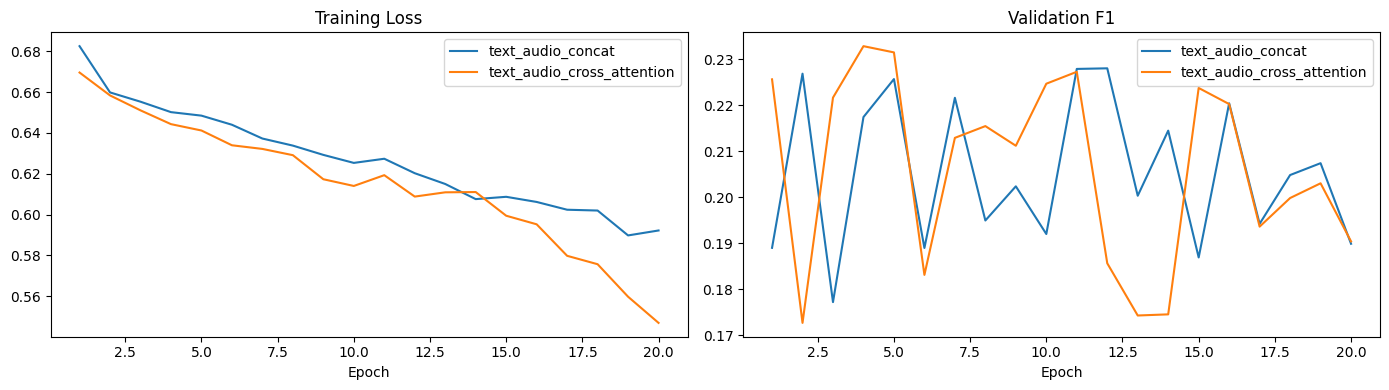

saved: /work/ccs_2/pipeline-and-data/pipeline_artifacts/training_curves_v2_20260528_235137.png


In [12]:
import matplotlib.pyplot as plt
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for model_name, history in histories.items():
    epochs_range = range(1, len(history) + 1)
    axes[0].plot(epochs_range, history["loss"],  label=model_name)
    axes[1].plot(epochs_range, history["f1_1"], label=model_name)

axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].set_title("Validation F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
path = cfg.artifact_dir / f"training_curves_v2_{timestamp}.png"
plt.savefig(path, dpi=150)
plt.show()
print("saved:", path)

## 8  Reading The Results

The key comparison within each test language:

```
text_only  vs  text_audio_concat  vs  text_audio_cross_attention
```

If text+audio improves F1 on fr/es/hu relative to text-only, that supports the
hypothesis that audio (via HuBERT prosodic features) helps cross-lingual transfer
for humor prediction — even though the audio encoder was never fine-tuned on
non-English data.

### Expected improvements over v1

| Source | Mechanism | Expected gain |
|---|---|---|
| Multilingual text encoder | Directly represents fr/es/hu tokens correctly | +5–15 F1 on fr/es/hu |
| HuBERT audio features | Richer prosodic signal vs Whisper | +2–5 F1 on concat/cross-attn |
| pos_weight loss fix | Calibrates decision threshold for non-English test sets | +3–8 F1 on all languages |
| Lookahead labels | Removes systematic false-negatives | +1–3 F1 globally |
| Smaller fusion head | Reduces English-specific memorisation | Closer en↔fr/es/hu gap |

## 9  Replacing The Label Module

If `AnnotationLaughterDetector` does not yet accept `lookahead_sec`, use
this drop-in subclass:

```python
class LookaheadAnnotationLaughterDetector(AnnotationLaughterDetector):
    """Extends the annotation detector with a forward lookahead window."""

    def __init__(self, cfg, lookahead_sec: float = 0.5):
        super().__init__(cfg)
        self.lookahead_sec = lookahead_sec

    def detect(self, row) -> list[tuple[float, float]]:
        """Return laughter intervals that overlap [start, end + lookahead_sec]."""
        intervals = super().detect(row)
        effective_end = row["end"] + self.lookahead_sec
        return [
            (s, e) for s, e in intervals
            if s < effective_end and e > row["start"]
        ]
```

Swap in:
```python
laughter_detector = LookaheadAnnotationLaughterDetector(cfg, lookahead_sec=0.5)
```

---

## 10  Swapping the audio encoder (future)

If you want to add prosodic hand-crafted features on top of HuBERT:

```python
# pip install praat-parselmouth crepe
import parselmouth, crepe

def extract_prosodic_features(wav: np.ndarray, sr: int) -> np.ndarray:
    """Returns a (T,) energy envelope and scalar pitch statistics."""
    snd = parselmouth.Sound(wav, sr)
    pitch = snd.to_pitch()
    intensity = snd.to_intensity()
    f0 = pitch.selected_array['frequency']
    f0[f0 == 0] = np.nan
    return np.array([
        np.nanmean(f0), np.nanstd(f0),          # mean/std pitch
        intensity.values.mean(),                 # mean intensity
        intensity.values.std(),                  # intensity variability
    ])
```

Concatenate these 4 scalars to the audio pooled vector before the fusion head.
They are language-agnostic and provide a very cheap complementary signal.